# Complex Networks Computational Session
# Adjacency Matrix, Random Graphs, and Stochastic Block Models (SBM)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
from scipy import sparse

In [2]:
# Function to visualize an adjacency matrix
def plot_adjacency_matrix(adj_matrix, title="Adjacency Matrix"):
    plt.figure(figsize=(6,6))
    plt.imshow(adj_matrix, cmap='gray_r', interpolation='none')
    plt.title(title)
    plt.colorbar(label="Edge Weight")
    plt.show()

# Check if A is symmetric (difference between A and A.T is zero) 
#def is_symmetric(A):
#    return np.all(A - A.T == 0)

# same with np.isclose
def is_symmetric(A):
    return np.allclose(A, A.T)



In [3]:
# 1. Construct a small adjacency matrix manually
adj_matrix = np.array([
    [0, 1, 1, 0],
    [1, 0, 1, 1],
    [1, 1, 0, 1],
    [0, 1, 1, 0]
])

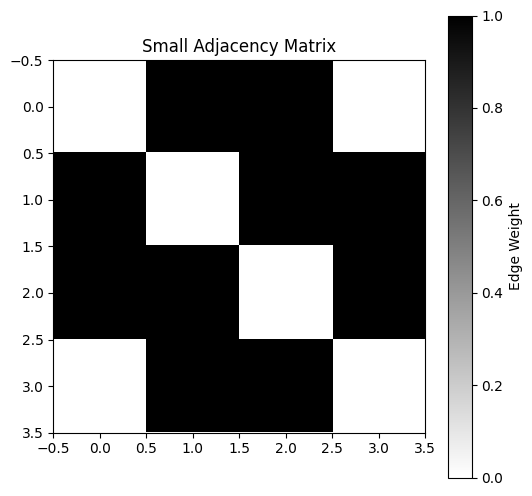

In [4]:
plot_adjacency_matrix(adj_matrix, "Small Adjacency Matrix")

## Graphs (toy models)
### Lattices

In [5]:
# 2.1 Lattice Graph
def generate_lattice(n):
    adj = np.zeros((n, n))
    adj[0,n-1]=1
    adj[n-1,0]=1
    adj[0,1]=1
    adj[n-1,n-2]=1
    for i in range(1,n-1):
        adj[i, i-1] = 1  # Connect to previous node
        adj[i, i+1] = 1  # Connect to next node
    return adj

#def generate_lattice(n):
#   adj = np.zeros((n, n))
#   for i in range(n):
#       adj[i, (i-1) % n] = 1  # Connect to previous node
#       adj[i, (i+1) % n] = 1  # Connect to next node
#   return adj

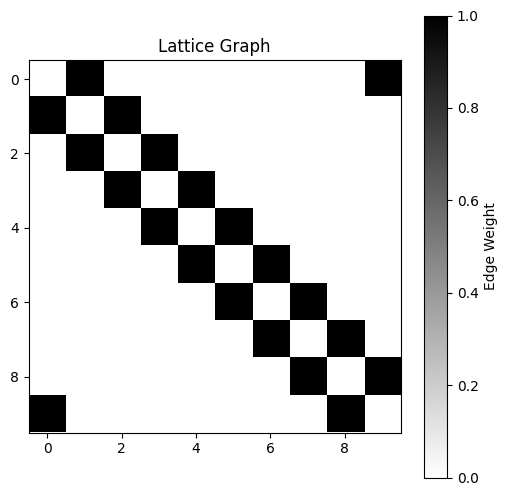

In [6]:
A=generate_lattice(10)
plot_adjacency_matrix(A, "Lattice Graph")

In [7]:
print(sparse.csr_matrix(A))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20 stored elements and shape (10, 10)>
  Coords	Values
  (0, 1)	1.0
  (0, 9)	1.0
  (1, 0)	1.0
  (1, 2)	1.0
  (2, 1)	1.0
  (2, 3)	1.0
  (3, 2)	1.0
  (3, 4)	1.0
  (4, 3)	1.0
  (4, 5)	1.0
  (5, 4)	1.0
  (5, 6)	1.0
  (6, 5)	1.0
  (6, 7)	1.0
  (7, 6)	1.0
  (7, 8)	1.0
  (8, 7)	1.0
  (8, 9)	1.0
  (9, 0)	1.0
  (9, 8)	1.0


In [8]:
print(sys.getsizeof(A))
print(sys.getsizeof(sparse.csr_matrix(A)))

928
48


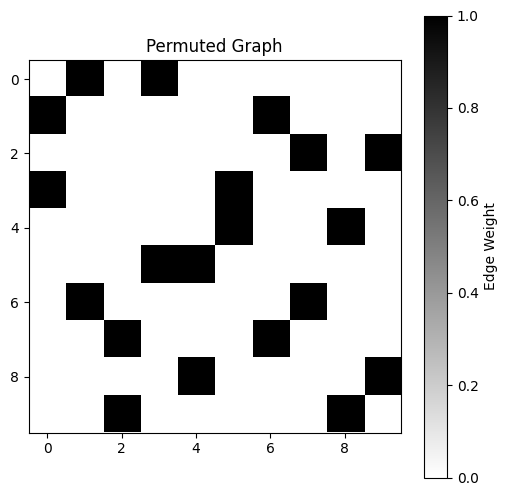

In [9]:
# random permutation P^T A P

n = A.shape[0]

#  permutation matrix  (obtained from shuffling the identity matrix)
perm = np.random.permutation(n)
P = np.eye(n)[perm]

# similarity transformation of A using P
A_perm = P.T @ A @ P
plot_adjacency_matrix(A_perm, "Permuted Graph")


In [12]:
# Eigenvalues of the adjacency matrix
eigenvalues = np.linalg.eigvals(A_perm)
print("Eigenvalues of the adjacency matrix:")
pd.Series(eigenvalues).describe()

Eigenvalues of the adjacency matrix:


count    1.000000e+01
mean     3.108624e-16
std      1.490712e+00
min     -2.000000e+00
25%     -1.368034e+00
50%      0.000000e+00
75%      1.368034e+00
max      2.000000e+00
dtype: float64

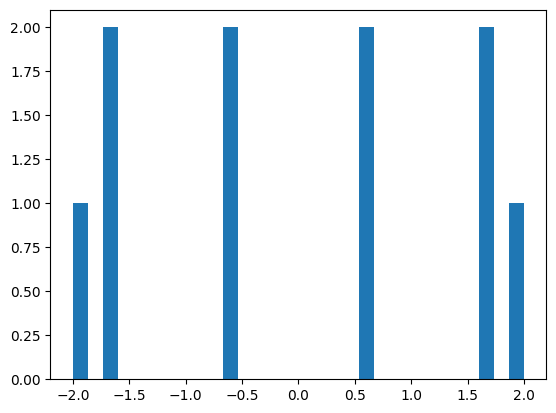

In [13]:
plt.hist(eigenvalues, bins=30);

In [38]:
# Bidimensional Lattice
def generate_bidim_lattice(n):
    adj = np.zeros((n**2, n**2))
    for i in range(n):
        for j in range(n):
            node = i*n + j
            adj[node, (i-1) % n * n + j] = 1  # Connect to node above
            adj[node, (i+1) % n * n + j] = 1  # Connect to node below
            adj[node, i * n + (j-1) % n] = 1  # Connect to node on the left
            adj[node, i * n + (j+1) % n] = 1  # Connect to node on the right
    return adj

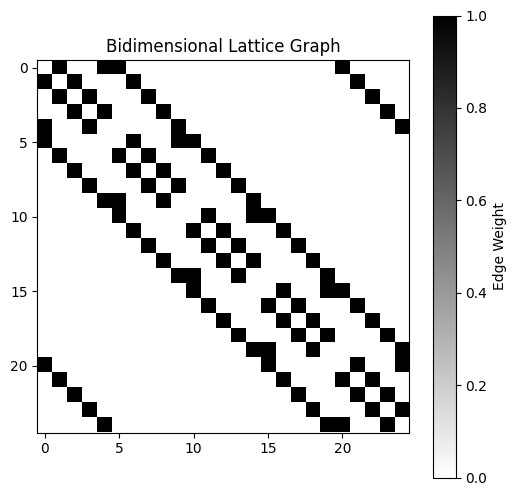

In [51]:
A=generate_bidim_lattice(5)
plot_adjacency_matrix(A, "Bidimensional Lattice Graph")

In [52]:
eigenvalues = np.linalg.eigvals(A)
# cast to real
eigenvalues = np.real(eigenvalues)
print("Eigenvalues of the adjacency matrix:")
pd.Series(eigenvalues).describe()

Eigenvalues of the adjacency matrix:


count    2.500000e+01
mean    -1.776357e-17
std      2.041241e+00
min     -3.236068e+00
25%     -1.000000e+00
50%      3.819660e-01
75%      1.236068e+00
max      4.000000e+00
dtype: float64

In [53]:
is_symmetric(A)

True

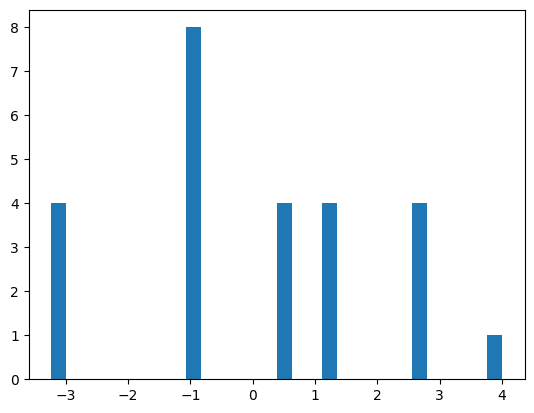

In [54]:
plt.hist(eigenvalues, bins=30);

## Bipartite graph
### Diseasome
Here we are going to use real data from the Diseasome network (Gog et al., 2007). 

In [101]:
edgelist= pd.read_csv("https://raw.githubusercontent.com/FraDurazzi/CNLab/refs/heads/master/data/diseasome_bipartite_net.txt",sep=' ')
# Add "D" prefix to disease nodes and "G" prefix to gene nodes
edgelist['DiseaseID']= "D" + edgelist['#Disease_id'].astype(str)
edgelist['GeneID']= "G" + edgelist['Entrez_id'].astype(str)
edgelist

,#Disease_id,Entrez_id,DiseaseID,GeneID
0,1,1586,D1,G1586
1,3,3028,D3,G3028
2,4,36,D4,G36
3,5,3284,D5,G3284
4,6,3033,D6,G3033
...,...,...,...,...
2668,9039,285362,D9039,G285362
2669,9308,183,D9308,G183
2670,9308,185,D9308,G185
2671,9308,1636,D9308,G1636


In [102]:
diseases= edgelist['DiseaseID'].unique()
Ndiseases= len(diseases)
print(f"Number of unique diseases: {Ndiseases}")
genes= edgelist['GeneID'].unique()
Ngenes= len(genes)
print(f"Number of unique genes: {Ngenes}")

Number of unique diseases: 1284
Number of unique genes: 1777


In [103]:
import networkx as nx
G= nx.Graph()
G.add_nodes_from(diseases, bipartite=0)
G.add_nodes_from(genes, bipartite=1)
for _, row in edgelist.iterrows():
    G.add_edge(row['DiseaseID'], row['GeneID'])

nx.is_bipartite(G)

True

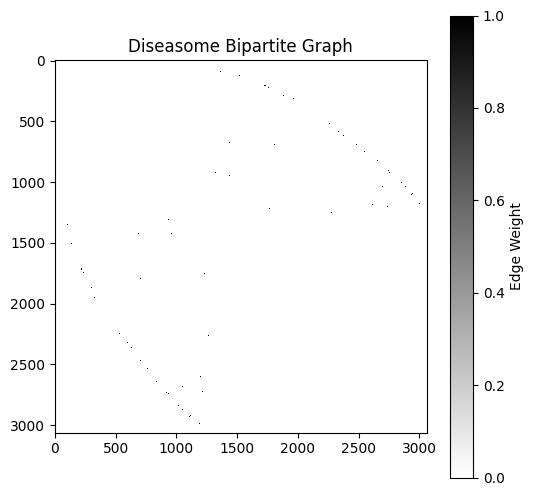

In [104]:
A=nx.adjacency_matrix(G).todense()
plot_adjacency_matrix(A, "Diseasome Bipartite Graph")

In [66]:
A[:Ndiseases, :Ndiseases].sum()

np.int64(0)

In [67]:
A[Ndiseases:, Ndiseases:].sum()

np.int64(0)

In [68]:
A[Ndiseases:, :Ndiseases].sum()

np.int64(2673)

(1284, 1284)


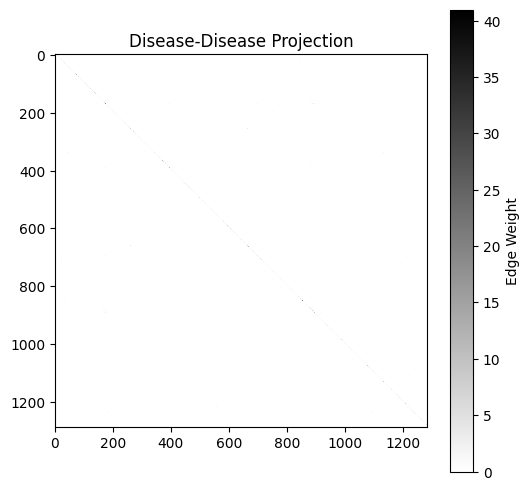

In [70]:
# Create disease-disease projection
Adis = A[:Ndiseases, Ndiseases:] @ A[:Ndiseases, Ndiseases:].T
print(Adis.shape)
plot_adjacency_matrix(Adis, "Disease-Disease Projection")

In [75]:
Adis.sum()-np.diag(Adis).sum() # remove diagonal elements (self-loops)

np.int64(3308)

In [78]:
np.diag(np.diag(Adis))

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 2, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 4]], shape=(1284, 1284))

In [79]:
# remove diagonal elements (self-loops)
Adis = Adis - np.diag(np.diag(Adis))


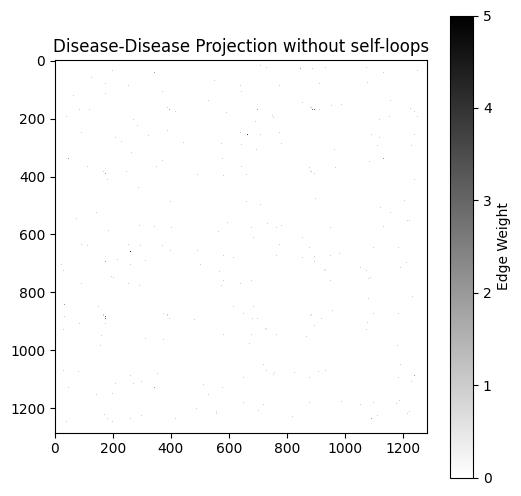

In [115]:
plot_adjacency_matrix(Adis, "Disease-Disease Projection without self-loops")

Number of nodes in disease-disease projection: 1284
Number of edges in disease-disease projection: 1527


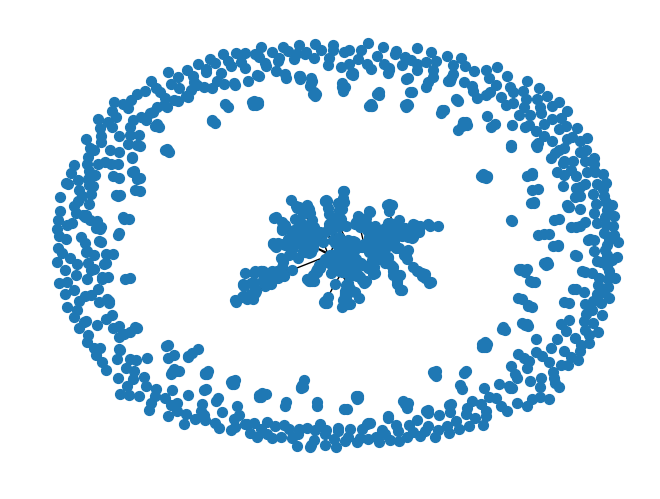

In [80]:
import networkx as nx
Adis_graph = nx.from_numpy_array(Adis)
print(f"Number of nodes in disease-disease projection: {Adis_graph.number_of_nodes()}")
print(f"Number of edges in disease-disease projection: {Adis_graph.number_of_edges()}")

nx.draw(Adis_graph, node_size=50, with_labels=False)

Number of nodes in disease-disease projection: 1284
Number of edges in disease-disease projection: 1527


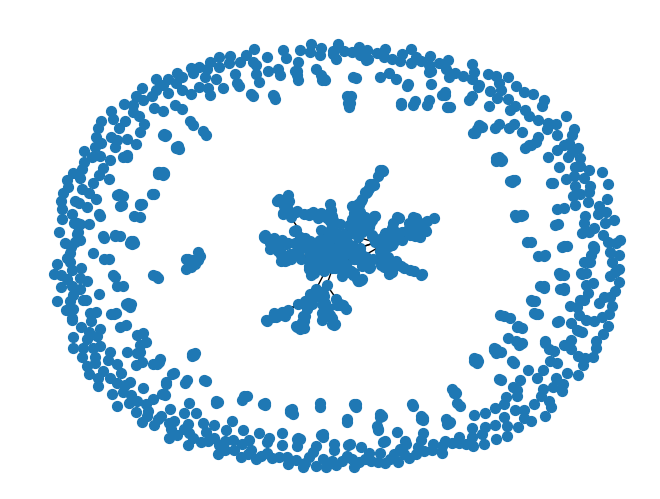

In [116]:
# We could have done directly in networkx
Gdis = nx.bipartite.weighted_projected_graph(G, diseases)
print(f"Number of nodes in disease-disease projection: {Gdis.number_of_nodes()}")
print(f"Number of edges in disease-disease projection: {Gdis.number_of_edges()}")

nx.draw(Gdis, node_size=50, with_labels=False)

In [105]:
# Load disease info
disease_info = pd.read_csv("https://raw.githubusercontent.com/FraDurazzi/CNLab/refs/heads/master/data/diseasome_DiseaseList.txt", sep='\t',skiprows=1, dtype={'Disease ID': str})
disease_info

,Disease ID,Name,Disorder class,Size (s),Degree (k),Class-degree (k),Genes implicated (Entrez ID) [comma-deliminated]
0,1,"17,20-lyase_deficiency",Endocrine,1,0,0,CYP17A1 (1586)
1,3,2-methyl-3-hydroxybutyryl-CoA_dehydrogenase_de...,Metabolic,1,0,0,HADH2 (3028)
2,4,2-methylbutyrylglycinuria,Metabolic,1,0,0,ACADSB (36)
3,5,"3-beta-hydroxysteroid_dehydrogenase,_type_II,_...",Metabolic,1,0,0,HSD3B2 (3284)
4,6,3-hydroxyacyl-CoA_dehydrogenase_deficiency,Metabolic,1,0,0,HADHSC (3033)
...,...,...,...,...,...,...,...
1279,8350,Combined_SAP_deficiency,Metabolic,1,2,2,PSAP (5660)
1280,9037,Multiple_myeloma,Cancer,2,1,0,"IRF4 (3662), LIG4 (3981)"
1281,9038,Multiple_sclerosis,Neurological,2,3,2,"CIITA (4261), PTPRC (5788)"
1282,9039,Multiple_sulfatase_deficiency,Metabolic,1,0,0,SUMF1 (285362)


In [117]:
for node in Gdis.nodes():
    dis_id= str(node)[1:]  # remove "D" prefix
    dis_name = disease_info.loc[disease_info['Disease ID'] == dis_id, 'Name'].values[0]
    dis_class = disease_info.loc[disease_info['Disease ID'] == dis_id, 'Disorder class'].values[0]
    Gdis.nodes[node]['name'] = dis_name
    Gdis.nodes[node]['class'] = dis_class

In [118]:
# Extract large component
largest_cc = max(nx.connected_components(Gdis), key=len)
Gdis_lcc = Gdis.subgraph(largest_cc).copy()
print(f"Number of nodes in largest connected component: {Gdis_lcc.number_of_nodes()}")
print(f"Number of edges in largest connected component: {Gdis_lcc.number_of_edges()}")

Number of nodes in largest connected component: 516
Number of edges in largest connected component: 1188


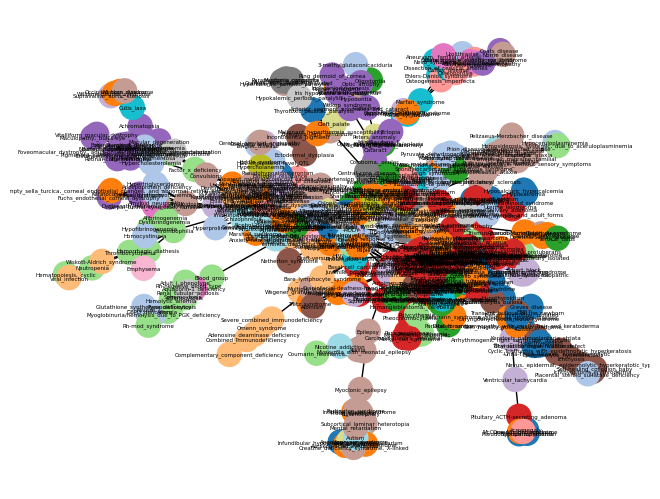

In [119]:
# Draw, color by class and print labels
unique_classes = disease_info['Disorder class'].unique()
class_colors = {cls: plt.cm.tab20(i) for i, cls in enumerate(unique_classes)}
node_colors = [class_colors[Gdis_lcc.nodes[node]['class']] for node in Gdis_lcc.nodes()]
labels = {node: Gdis_lcc.nodes[node]['name'] for node in Gdis_lcc.nodes()}
nx.draw(Gdis_lcc, node_color=node_colors, with_labels=True, font_size=4,labels=labels)

In [120]:
# Save Gdis_lcc to file, conserving node attributes
nx.write_graphml(Gdis_lcc, "data/disease_disease_projection_lcc.graphml")

## Random graphs
### Microcanonical ensemble of networks with N nodes and M edges
Analogy with fixed energy E (fixed number of links) 

In [9]:
N=100
M=2000

# Create n random graphs
n=100

Ms=np.zeros(n)
for i in tqdm(range(n)):
    A = np.zeros((N,N))
    for j in range(M):
        a = np.random.randint(0,N)
        b = np.random.randint(0,N)
        while a==b or A[a,b]==1:
            a = np.random.randint(0,N)
            b = np.random.randint(0,N)
        A[a,b]=1
        A[b,a]=1
    # Save number of edges
    Ms[i]=np.sum(A)/2


100%|██████████| 100/100 [00:02<00:00, 35.74it/s]


### Canonical ensemble of networks with N nodes (Erdos-Renyi graph)
Analogy with fixed temperature T -> the constraint is the expected value of the energy \<E\>, but i can fluctuate

In [17]:
N=100
p=0.1
n=100

Ms=np.zeros(n)
for i in tqdm(range(n)):
    # Matrix of random numbers between 0 and 1 (uniform distribution)
    A = np.random.rand(N,N)
    # Create adjacency matrix
    A = A<p
    # Make it symmetric
    A = np.triu(A,1)
    A = A + A.T
    # Save number of edges
    Ms[i]=np.sum(A)/2

100%|██████████| 100/100 [00:00<00:00, 3745.78it/s]


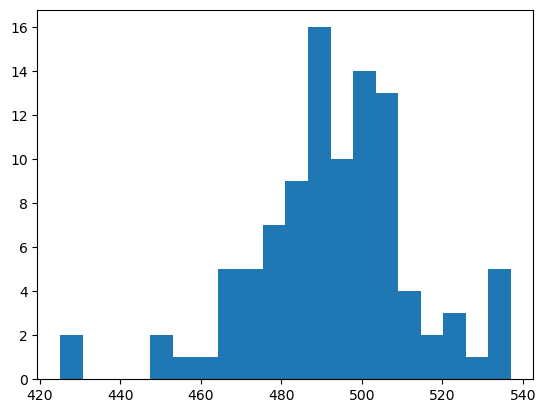

In [18]:
plt.hist(Ms, bins=20);

In [19]:
def erdos_renyi(N,p):
    A = np.random.rand(N,N)
    A = A<p
    A = np.triu(A,1)
    A = A + A.T
    return A


Number of edges: 4950.0
1.0


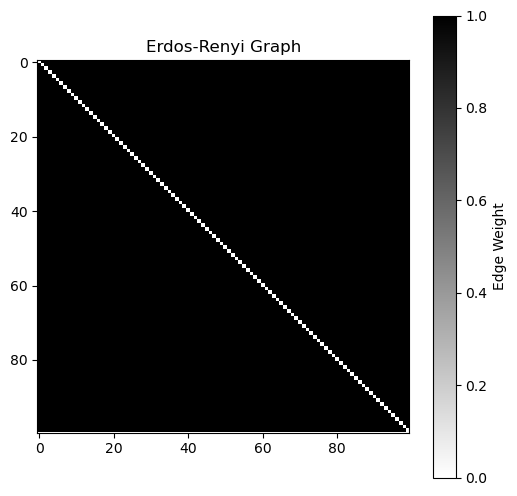

In [24]:
# Density
N=100
A=erdos_renyi(N,1)
M=np.sum(A)/2
print('Number of edges:',M)
density = M/(N*(N-1)/2)
print(density)
plot_adjacency_matrix(A, "Erdos-Renyi Graph")

Text(0, 0.5, 'st.dev / mean number of edges')

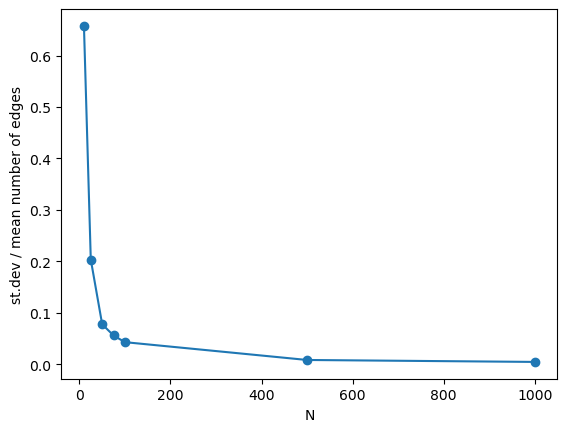

In [22]:
# Ratio between standard deviation and mean number of edges goes to zero as N increases (termodynamic limit)
n=100
Ns=[10,25,50,75,100,500,1000]
ratios=[]
for N in Ns:
    Ms=np.zeros(n)
    for i in range(n):
        A = erdos_renyi(N,0.1)
        M=np.sum(A)/2
        Ms[i]=M
    ratios.append(np.std(Ms)/np.mean(M))

plt.plot(Ns,ratios,'o-')
plt.xlabel('N')
plt.ylabel('st.dev / mean number of edges')

## Stochastic Block Model (SBM)

In [9]:
def generate_sbm(sizes, p_in, p_out):
    n = sum(sizes)
    adj = np.zeros((n, n))
    # Intra-community links
    start = 0
    for i, size in enumerate(sizes):
        end = start + size
        adj[start:end, start:end] = np.random.rand(size, size) < p_in[i]
        #simmetrize
        adj[start:end, start:end] = np.triu(adj[start:end, start:end],1)
        adj[start:end, start:end] = adj[start:end, start:end] + adj[start:end, start:end].T
        start = end
    # Inter-community links
    for i in range(len(sizes)):
        for j in range(i+1, len(sizes)):
            start_i, end_i = sum(sizes[:i]), sum(sizes[:i+1])
            start_j, end_j = sum(sizes[:j]), sum(sizes[:j+1])
            adj[start_i:end_i, start_j:end_j] = np.random.rand(end_i-start_i, end_j-start_j) < p_out[i,j]
            adj[start_j:end_j, start_i:end_i] = adj[start_i:end_i, start_j:end_j].T
    return adj

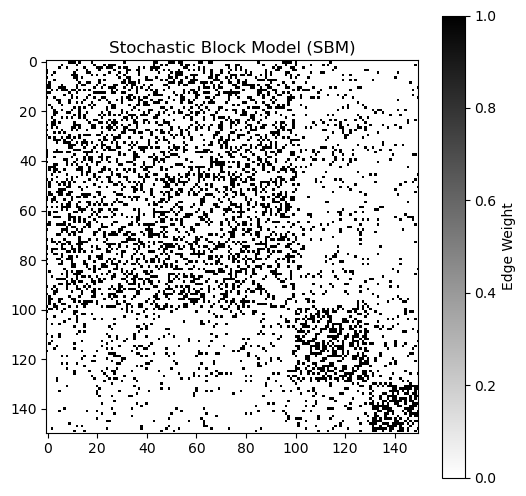

In [10]:
sizes = [100, 30, 20]  # Three communities of size 5
p_in = [0.3, 0.4, 0.5]  # High intra-cluster density
p_out = np.array([[0, 0.1, 0.05], 
                  [0.1, 0, 0.1],
                  [0.05, 0.1, 0]])  # Sparse inter-cluster density

# N.B. actually it is considering only the upper triangular part of the block connectivity matrix

sbm_adj = generate_sbm(sizes, p_in, p_out)
plot_adjacency_matrix(sbm_adj, "Stochastic Block Model (SBM)")

### Giant component transition on ER graphs

In [13]:
N=200

# Matrix of random numbers between 0 and 1 (uniform distribution)
A = np.random.rand(N,N)
ps=np.logspace(-4,0,20)
Ms=np.zeros(len(ps))
GCs=np.zeros(len(ps))
for i,p in tqdm(enumerate(ps)):
    # Create adjacency matrix
    Ai = A<p
    # Make it symmetric
    Ai = np.triu(Ai,1)
    Ai = Ai + Ai.T
    # Create a graph
    G = nx.Graph(Ai)
    
    components = list(nx.connected_components(G))
    # Get the giant component
    comp_sizes = [len(comp) for comp in components]
    GCs[i] = max(comp_sizes)

    

20it [00:02,  9.10it/s]


Text(0, 0.5, 'Size of the giant component')

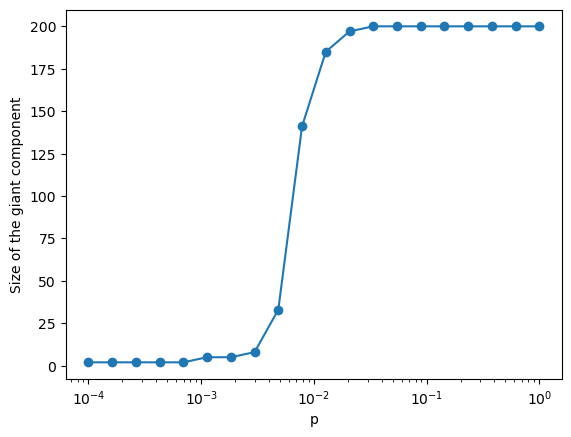

In [14]:
# Plot p and the size of the giant component
plt.plot(ps,GCs,'-o')
plt.xscale('log')
plt.xlabel('p')
plt.ylabel('Size of the giant component')